# Zadanie 1: Prognozowanie Wielowymiarowych Serii Czasowych (Weather Forecasting)

## 1. Wprowadzenie i Cel Eksperymentu
Celem tego zadania jest zaimplementowanie, wytrenowanie i porównanie dwóch architektur głębokiego uczenia w zadaniu wielokrokowego, wielowymiarowego prognozowania serii czasowych (Multivariate Multi-Step Time Series Forecasting). 

Eksperyment przeprowadzamy na zbiorze danych stacji meteorologicznej **Jena Weather Dataset**. Naszym zadaniem jest przewidywanie wartości **trzech skorelowanych cech jednocześnie** na kolejne **7 dni** (horyzont prognozy: `forecast_len = 7`) na podstawie historii z poprzednich **30 dni** (`seq_len = 30`). 

Wykorzystywane cechy:
1. **T (degC)** — Temperatura powietrza,
2. **p (mbar)** — Ciśnienie atmosferyczne,
3. **rh (%)** — Wilgotność względna.

Porównaniu podlegają dwie główne klasy modeli:
* **Transformer (Decoder-Only Architecture)** — Nowoczesny model oparty całkowicie na mechanizmach samoatencji (Self-Attention).
* **LSTM (Sequence-to-Sequence z Autoregresją)** — Klasyczna, bazowa architektura rekurencyjna dedykowana do sekwencji.

# A

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import math
import os

### Data preporation

In [64]:
csv_path = os.path.join('jena_data', 'mpi_saale_2021b.csv')

df = pd.read_csv(csv_path)

df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
df = df.dropna(subset=['Date Time']).sort_values('Date Time').reset_index(drop=True)

features = ['T (degC)', 'p (mbar)', 'rh (%)']
data = df[features].values

### Data scaling

In [65]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

## Window preporation

In [66]:
seq_len = 30
forecast_len = 7 
num_features = len(features)

def create_multivariate_sequences(data, seq_len, forecast_len):
    X, Y = [], []
    for i in range(len(data) - seq_len - forecast_len + 1):
        X.append(data[i : i + seq_len])
        Y.append(data[i + seq_len : i + seq_len + forecast_len])
    return np.array(X), np.array(Y)

X_data, y_data = create_multivariate_sequences(data_scaled, seq_len, forecast_len)

print(f"Shapes: X_data: {X_data.shape}, y_data: {y_data.shape}")

Shapes: X_data: (26460, 30, 3), y_data: (26460, 7, 3)


### Train/val/test split (60/20/20)

In [67]:
split_idx = int(len(X_data) * 0.8)
X_train, y_train = X_data[:split_idx], y_data[:split_idx]
X_test, y_test = X_data[split_idx:], y_data[split_idx:]

split_idx = int(len(X_train) * 0.75)
X_val, y_val = X_train[split_idx:], y_train[split_idx:]
X_train, y_train = X_train[:split_idx], y_train[:split_idx]


# to tensors

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(f"Shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shapes: X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Shapes: X_test: {X_test.shape}, y_test: {y_test.shape}")


Shapes: X_train: (15876, 30, 3), y_train: (15876, 7, 3)
Shapes: X_val: (5292, 30, 3), y_val: (5292, 7, 3)
Shapes: X_test: (5292, 30, 3), y_test: (5292, 7, 3)


## B

## Architektura Transformera: Encoder-Decoder vs. Decoder-Only

### Dlaczego model Decoder-Only jest wystarczający i efektywny w prognozowaniu serii czasowych?
Oryginalna architektura Transformera została zaprojektowana do NLP, gdzie struktura **Encoder-Decoder** jest naturalna: encoder przetwarza tekst źródłowy (np. po polsku), a decoder generuje tekst docelowy (np. po angielsku).

W przypadku prognozowania serii czasowych sytuacja wygląda inaczej:
1.  **Ciągłość domeny:** Sygnał wejściowy (historia) i sygnał wyjściowy (przyszłość) znajdują się w tej samej przestrzeni cech fizycznych (temperatura, ciśnienie itp.). Nie ma potrzeby mapowania między dwoma różnymi "językami".
2.  **Samoatencja przyczynowa (Causal Self-Attention):** Stosując architekturę **Decoder-Only** z odpowiednio nałożoną maską przyczynową (Causal Mask), wymuszamy na modelu, aby dany krok czasowy mógł agregować informacje wyłącznie z kroków przeszłych i obecnego. Zapobiega to wyciekowi danych z przyszłości (Data Leakage).
3.  **Efektywność i prostota:** Architektura typu Decoder-Only (podobnie jak modele GPT w NLP) jest prostsza w implementacji, ma mniej parametrów niż pełny układ Encoder-Decoder o tej samej szerokości sieci i pozwala na bezpośrednie modelowanie zależności autoregresyjnych w jednym bloku atencji.

### A. Transformer Decoder-Only
* **Input Projection:** Ponieważ cechy wejściowe mają wymiar `num_features = 3`, rzutujemy je liniowo (`nn.Linear`) do przestrzeni ukrytej o wymiarze `d_model = 64`.
* **Positional Encoding:** Ponieważ mechanizm atencji nie rozróżnia kolejności danych (jest permutacyjnie niezmienniczy), dodajemy sinusoidalne kodowanie pozycyjne, które dostarcza modelowi informacji o upływie czasu.
* **Causal Mask:** Wykorzystujemy funkcję `generate_square_subsequent_mask`, aby zablokować możliwość zaglądania w przyszłość podczas operacji samoatencji.

### B. LSTM Seq2Seq (Autoregresyjny)
* **Encoder:** Przetwarza wejściową sekwencję 30 dni i kompresuje ją do stanów ukrytych (Hidden State $h_n$ i Cell State $c_n$).
* **Decoder:** Zainicjalizowany końcowymi stanami encodera, krok po kroku (w pętli o długości 7) generuje prognozę na kolejny dzień. Wykorzystuje podejście **autoregresyjne**: predykcja z kroku $t$ staje się bezpośrednio wejściem dla kroku $t+1$.

### Positional Encoding

In [68]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        seq_len = x.size(1)
        x = x + self.pe[:seq_len, :].unsqueeze(0)
        return x

### Transformer

In [69]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2, forecast_len=7):
        super().__init__()
        self.forecast_len = forecast_len
        self.d_model = d_model
        
        self.num_features = num_features 
        
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model*4, 
            dropout=0.1, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, forecast_len * num_features)

    def forward(self, src):
        src = self.input_proj(src)       # [batch, 30, d_model]
        src = self.pos_encoder(src)      # [batch, 30, d_model]
        
        # Causal Mask, żeby zapobiec data leakage
        seq_len = src.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(src.device)
        
        out = self.transformer(src, mask=causal_mask, is_causal=True) # [batch, 30, d_model]
        
        last_step_out = out[:, -1, :]    # [batch, d_model]
        
        preds = self.output_proj(last_step_out) # [batch, 21]
        
        preds = preds.view(-1, self.forecast_len, self.num_features) # [batch, 7, 3]
        
        return preds

## C

In [70]:
import time
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [71]:
batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("mps" if torch.mps.is_available() else "cpu")

print(f"Device: {device}")

Device: mps


In [72]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device):
    train_losses = []
    val_losses = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            batch_losses.append(loss.item())
            
        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                val_preds = model(X_val_batch)
                v_loss = criterion(val_preds, y_val_batch)
                val_batch_losses.append(v_loss.item())
                
        avg_val_loss = np.mean(val_batch_losses)
        val_losses.append(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            scheduler.step(avg_val_loss)
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss (MSE): {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f} | LR: {current_lr:.6f}")
        
    total_time = time.time() - start_time
    print(f"\nTrening zakończony w {total_time:.2f} s.")
    
    return train_losses, val_losses, total_time

In [73]:
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.numpy())
            
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    return all_preds, all_targets

In [74]:
def plot_learning_curves(train_losses, val_losses, model_name="Model"):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Validation Loss', marker='s')
    plt.title(f'Krzywe uczenia - {model_name}')
    plt.xlabel('Epoka')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Epoch [01/25] | Train Loss (MSE): 0.07012 | Val Loss: 0.03852 | LR: 0.001000
Epoch [02/25] | Train Loss (MSE): 0.03443 | Val Loss: 0.03214 | LR: 0.001000
Epoch [03/25] | Train Loss (MSE): 0.03126 | Val Loss: 0.03509 | LR: 0.001000
Epoch [04/25] | Train Loss (MSE): 0.02984 | Val Loss: 0.02969 | LR: 0.001000
Epoch [05/25] | Train Loss (MSE): 0.02959 | Val Loss: 0.02974 | LR: 0.001000
Epoch [06/25] | Train Loss (MSE): 0.02811 | Val Loss: 0.02701 | LR: 0.001000
Epoch [07/25] | Train Loss (MSE): 0.02753 | Val Loss: 0.02850 | LR: 0.001000
Epoch [08/25] | Train Loss (MSE): 0.02738 | Val Loss: 0.02870 | LR: 0.001000
Epoch [09/25] | Train Loss (MSE): 0.02719 | Val Loss: 0.03497 | LR: 0.001000
Epoch [10/25] | Train Loss (MSE): 0.02676 | Val Loss: 0.03231 | LR: 0.001000
Epoch [11/25] | Train Loss (MSE): 0.02585 | Val Loss: 0.03575 | LR: 0.000500
Epoch [12/25] | Train Loss (MSE): 0.02521 | Val Loss: 0.03488 | LR: 0.000500
Epoch [13/25] | Train Loss (MSE): 0.02475 | Val Loss: 0.02873 | LR: 0.000500

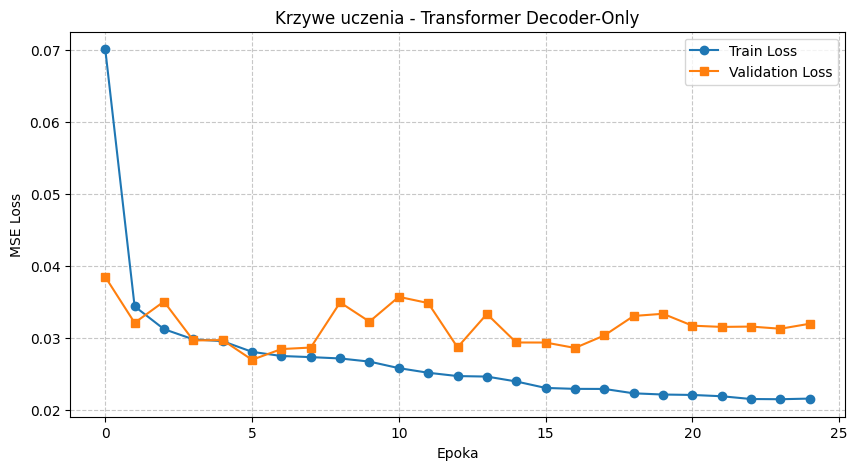

In [75]:
model_tf = TimeSeriesTransformer(
    num_features=3, 
    d_model=64, 
    nhead=4, 
    num_layers=2, 
    forecast_len=7
).to(device)

criterion = nn.MSELoss()
optimizer_tf = optim.AdamW(model_tf.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_tf = optim.lr_scheduler.ReduceLROnPlateau(optimizer_tf, mode='min', factor=0.5, patience=3)

epochs = 25
train_losses_tf, val_losses_tf, time_tf = train_model(
    model_tf, train_loader, val_loader, criterion, optimizer_tf, scheduler_tf, epochs, device
)

plot_learning_curves(train_losses_tf, val_losses_tf, "Transformer Decoder-Only")

preds_tf, targets_tf = evaluate_model(model_tf, test_loader, device)

## D

In [76]:
class LSTMSeq2Seq(nn.Module):
    def __init__(self, num_features, hidden_dim=64, num_layers=2, forecast_len=7):
        super().__init__()
        self.num_features = num_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.forecast_len = forecast_len
        
        self.encoder = nn.LSTM(
            input_size=num_features, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.1
        )
        
        # Input_size do decodera to num_feature, bo będziemy go karmić jego własnymi predykcjami
        self.decoder = nn.LSTM(
            input_size=num_features, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.1
        )
        
        self.output_proj = nn.Linear(hidden_dim, num_features)

    def forward(self, src):
        # [batch_size, 30, num_features]
        batch_size = src.size(0)
        
        # _ to outputy dla każdego z 30 dni, nie potrzebujemy ich
        # hidden to (h_n, c_n) z ostatniego kroku
        _, hidden = self.encoder(src) 
        
        outputs = []
        
        # Jako pierwsze wejście decodera (w kroku t=0) dajemy OSTATNIĄ wartość z historii (src[:, -1, :])
        decoder_input = src[:, -1, :].unsqueeze(1) # [batch, 1, num_features]
        
        # autoregresja
        for t in range(self.forecast_len):
            # Przepuszczamy 1 krok przez decodera (przekazując stany 'hidden' z poprzedniego kroku)
            dec_out, hidden = self.decoder(decoder_input, hidden)
            
            # Mapujemy stan decodera na przewidywane 3 cechy
            pred = self.output_proj(dec_out) # [batch, 1, 3]
            outputs.append(pred)
            
            # W "testowaniu/treningu" podajemy predykcję z kroku t jako wejście do kroku t+1
            decoder_input = pred 
            
        # Łączymy wszystkie 7 kroków w tensor wzdłuż osi czasu (dim=1)
        outputs = torch.cat(outputs, dim=1) # [batch, 7, 3]
        
        return outputs

Epoch [01/25] | Train Loss (MSE): 0.16101 | Val Loss: 0.09978 | LR: 0.001000
Epoch [02/25] | Train Loss (MSE): 0.04874 | Val Loss: 0.08028 | LR: 0.001000
Epoch [03/25] | Train Loss (MSE): 0.04347 | Val Loss: 0.06492 | LR: 0.001000
Epoch [04/25] | Train Loss (MSE): 0.04674 | Val Loss: 0.06180 | LR: 0.001000
Epoch [05/25] | Train Loss (MSE): 0.03669 | Val Loss: 0.06518 | LR: 0.001000
Epoch [06/25] | Train Loss (MSE): 0.03402 | Val Loss: 0.06195 | LR: 0.001000
Epoch [07/25] | Train Loss (MSE): 0.03423 | Val Loss: 0.05965 | LR: 0.001000
Epoch [08/25] | Train Loss (MSE): 0.03144 | Val Loss: 0.05934 | LR: 0.001000
Epoch [09/25] | Train Loss (MSE): 0.02978 | Val Loss: 0.06144 | LR: 0.001000
Epoch [10/25] | Train Loss (MSE): 0.02946 | Val Loss: 0.06183 | LR: 0.001000
Epoch [11/25] | Train Loss (MSE): 0.03177 | Val Loss: 0.05988 | LR: 0.001000
Epoch [12/25] | Train Loss (MSE): 0.03036 | Val Loss: 0.07074 | LR: 0.001000
Epoch [13/25] | Train Loss (MSE): 0.02737 | Val Loss: 0.05548 | LR: 0.000500

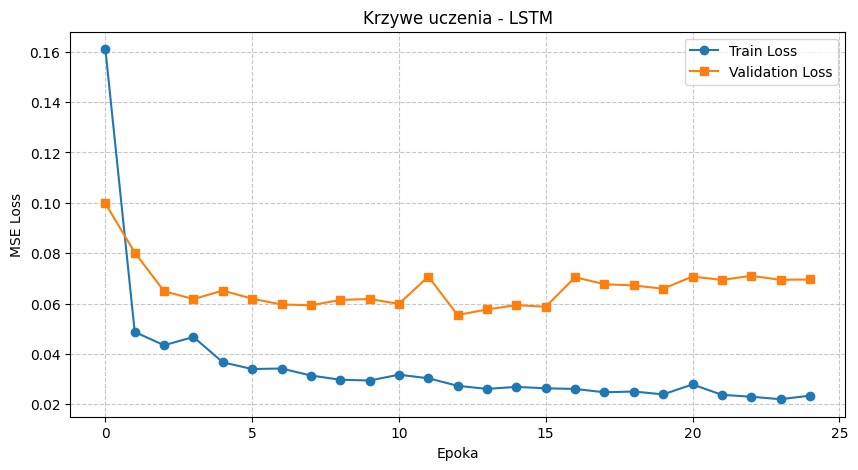

In [77]:
model_lstm = LSTMSeq2Seq(
    num_features=3, 
    hidden_dim=64, 
    num_layers=2, 
    forecast_len=7
).to(device)

criterion = nn.MSELoss()
optimizer_lstm = optim.AdamW(model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_lstm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm, mode='min', factor=0.5, patience=3)

epochs = 25
train_losses_lstm, val_losses_lstm, time_lstm = train_model(
    model_lstm, train_loader, val_loader, criterion, optimizer_lstm, scheduler_lstm, epochs, device
)

plot_learning_curves(train_losses_lstm, val_losses_lstm, "LSTM")

preds_lstm, targets_lstm = evaluate_model(model_lstm, test_loader, device)

## E

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics_for_feature(preds, targets, scaler, feature_idx, feature_name):
    N, forecast_len, num_features = preds.shape
    
    # 1. Odwracanie skalowania (wymaga spłaszczenia do 2D i powrotu do 3D)
    preds_flat = preds.reshape(-1, num_features)
    targets_flat = targets.reshape(-1, num_features)
    
    # scaler.inverse_transform musi dostać 3 cechy, żeby zadziałał poprawnie
    preds_inv = scaler.inverse_transform(preds_flat).reshape(N, forecast_len, num_features)
    targets_inv = scaler.inverse_transform(targets_flat).reshape(N, forecast_len, num_features)
    
    # 2. Wyciągamy tylko interesującą nas cechę 
    p = preds_inv[:, :, feature_idx]
    t = targets_inv[:, :, feature_idx]
    
    metrics = {}
    
    # Ogólny błąd dla całego okna 7 dni
    metrics[f'{feature_name} - Overall MAE'] = mean_absolute_error(t, p)
    metrics[f'{feature_name} - Overall RMSE'] = np.sqrt(mean_squared_error(t, p))
    
    # Błąd dla konkretnych horyzontów czasowych (+1, +3, +7 dni)
    horizons = [(1, 0), (3, 2), (7, 6)]
    for day, idx in horizons:
        metrics[f'{feature_name} - Day +{day} MAE'] = mean_absolute_error(t[:, idx], p[:, idx])
        metrics[f'{feature_name} - Day +{day} RMSE'] = np.sqrt(mean_squared_error(t[:, idx], p[:, idx]))
        
    return metrics

def evaluate_all_features(preds, targets, scaler, feature_names):
    all_metrics = {}
    for idx, name in enumerate(feature_names):
        feature_metrics = calculate_metrics_for_feature(preds, targets, scaler, idx, name)
        all_metrics.update(feature_metrics)
    return all_metrics

In [83]:
# 1. Zbieramy surowe predykcje z obu modeli na zbiorze testowym
print("Zbieranie predykcji Transformera...")
preds_tf, targets_tf = evaluate_model(model_tf, test_loader, device)

print("Zbieranie predykcji LSTM...")
# (Upewnij się, że model LSTM był wcześniej wytrenowany!)
preds_lstm, targets_lstm = evaluate_model(model_lstm, test_loader, device)

# 2. Liczymy metryki dla wszystkich cech
feature_names = ['Temp (degC)', 'Press (mbar)', 'RH (%)']

metrics_tf_all = evaluate_all_features(preds_tf, targets_tf, scaler, feature_names)
metrics_lstm_all = evaluate_all_features(preds_lstm, targets_lstm, scaler, feature_names)

# 3. Tworzymy czytelną tabelę Pandas
df_metrics_all = pd.DataFrame([metrics_tf_all, metrics_lstm_all], index=['Transformer', 'LSTM'])

# Formatowanie tabeli dla lepszej czytelności (zamieniamy kolumny w MultiIndex)
# Ułatwi to analizę raportu, grupując wyniki po cechach
columns_tuples = [tuple(col.split(' - ')) for col in df_metrics_all.columns]
df_metrics_all.columns = pd.MultiIndex.from_tuples(columns_tuples, names=["Feature", "Metric"])

display(df_metrics_all.round(3))

Zbieranie predykcji Transformera...
Zbieranie predykcji LSTM...


Feature     Temp (degC)               ...     RH (%)            
Metric      Overall MAE Overall RMSE  ... Day +7 MAE Day +7 RMSE
Transformer       2.753        3.957  ...      3.802       5.237
LSTM              2.710        3.706  ...      6.936      10.114

[2 rows x 24 columns]

# F

In [80]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_tf = count_trainable_parameters(model_tf)
params_lstm = count_trainable_parameters(model_lstm)

time_tf_formatted = f"{time_tf:.1f} s"
time_lstm_formatted = f"{time_lstm:.1f} s"

perf_data = {
    'Model': ['Transformer (Decoder-Only)', 'LSTM (Seq2Seq)'],
    'Trainable Parameters': [params_tf, params_lstm],
    'Training Time': [time_tf_formatted, time_lstm_formatted]
}

df_perf = pd.DataFrame(perf_data).set_index('Model')

display(df_perf)

,Trainable Parameters,Training Time
Model,,
Transformer (Decoder-Only),101589,173.7 s
LSTM (Seq2Seq),102083,125.1 s


## G

In [81]:
print("Rozpoczynamy strojenie hiperparametrów...")
model_tf_tuned = TimeSeriesTransformer(
    num_features=3, 
    d_model=64, 
    nhead=8,       # Zmiana! 8 głów
    num_layers=1,  # Zmiana! Płytsza sieć
    forecast_len=7
).to(device)

optimizer_tuned = optim.AdamW(model_tf_tuned.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_tuned = optim.lr_scheduler.ReduceLROnPlateau(optimizer_tuned, mode='min', factor=0.5, patience=3)

train_losses_tuned, val_losses_tuned, time_tuned = train_model(
    model_tf_tuned, train_loader, val_loader, criterion, optimizer_tuned, scheduler_tuned, epochs=25, device=device
)

preds_tuned, targets_tuned = evaluate_model(model_tf_tuned, test_loader, device)

# Zestawienie czasów (dla Punktu G i F)
print("\n--- PORÓWNANIE CZASÓW TRENINGU ---")
print(f"Model Bazowy (2 layers, 4 heads): {time_tf:.1f} s")
print(f"Model Tuned (1 layer,  8 heads): {time_tuned:.1f} s")

# Sprawdzenie błędów dla Temperatury
metrics_tuned = calculate_metrics_for_feature(preds_tuned, targets_tuned, scaler, feature_idx=0, feature_name='Temp (degC)')
# Przypominam, że metryki bazowego Transformera mamy już w słowniku z kroku E

df_tuning = pd.DataFrame([metrics_tf_all, metrics_tuned], index=['TF Base (2L, 4H)', 'TF Tuned (1L, 8H)'])

# Formatujemy tak jak wcześniej
columns_tuples = [tuple(col.split(' - ')) for col in df_tuning.columns]
df_tuning.columns = pd.MultiIndex.from_tuples(columns_tuples, names=["Feature", "Metric"])

print("\n--- EFEKTY STROJENIA (Dla Temperatury) ---")
# Wyświetlamy tylko Temperaturę dla czytelności (możesz usunąć .xs, żeby pokazać wszystko)
display(df_tuning.xs('Temp (degC)', level='Feature', axis=1).round(3))

Rozpoczynamy strojenie hiperparametrów...
Epoch [01/25] | Train Loss (MSE): 0.07278 | Val Loss: 0.03706 | LR: 0.001000
Epoch [02/25] | Train Loss (MSE): 0.03391 | Val Loss: 0.03075 | LR: 0.001000
Epoch [03/25] | Train Loss (MSE): 0.03121 | Val Loss: 0.02725 | LR: 0.001000
Epoch [04/25] | Train Loss (MSE): 0.03049 | Val Loss: 0.03069 | LR: 0.001000
Epoch [05/25] | Train Loss (MSE): 0.02904 | Val Loss: 0.02823 | LR: 0.001000
Epoch [06/25] | Train Loss (MSE): 0.02859 | Val Loss: 0.03049 | LR: 0.001000
Epoch [07/25] | Train Loss (MSE): 0.02791 | Val Loss: 0.03051 | LR: 0.001000
Epoch [08/25] | Train Loss (MSE): 0.02655 | Val Loss: 0.02891 | LR: 0.000500
Epoch [09/25] | Train Loss (MSE): 0.02680 | Val Loss: 0.03157 | LR: 0.000500
Epoch [10/25] | Train Loss (MSE): 0.02670 | Val Loss: 0.02871 | LR: 0.000500
Epoch [11/25] | Train Loss (MSE): 0.02614 | Val Loss: 0.03150 | LR: 0.000500
Epoch [12/25] | Train Loss (MSE): 0.02538 | Val Loss: 0.02988 | LR: 0.000250
Epoch [13/25] | Train Loss (MSE): 

Metric,Overall MAE,Overall RMSE,Day +1 MAE,Day +1 RMSE,Day +3 MAE,Day +3 RMSE,Day +7 MAE,Day +7 RMSE
"TF Base (2L, 4H)",2.753,3.957,2.208,3.350,2.759,4.009,2.801,3.899
"TF Tuned (1L, 8H)",2.319,3.291,1.833,2.732,1.961,2.820,3.043,4.092


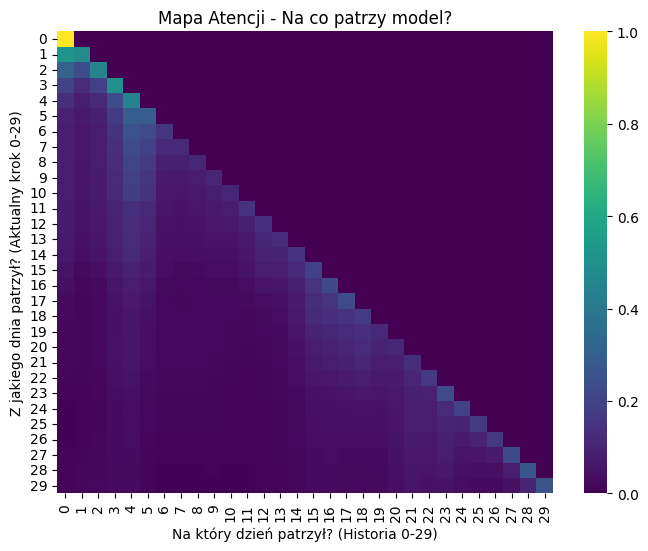

In [ ]:
import seaborn as sns


# 1. Bierzemy tylko JEDEN przykładowy zestaw danych z testów (np. pierwszy)
# unsqueeze(0) dodaje nam wymiar "batcha", więc mamy kształt: [1, 30, 3]
x_sample = X_test_t[0].unsqueeze(0).to(device)

# 2. Przygotowujemy ten sygnał tak, jak robi to nasz model na samym wejściu
# Zmieniamy 3 cechy na 64 i dodajemy pozycję (żeby model wiedział, który to dzień)
src = model_tf_tuned.input_proj(x_sample)
src = model_tf_tuned.pos_encoder(src)

# 3. Tworzymy maskę czasową na 30 dni (tzw. Causal Mask)
# To po to, żeby model w dniu 15 nie mógł "oszukiwać" i patrzeć na dzień 16
mask = nn.Transformer.generate_square_subsequent_mask(30).to(device)

# 4. "Włamanie" do modelu - bierzemy bezpośrednio PIERWSZĄ warstwę
pierwsza_warstwa = model_tf_tuned.transformer.layers[0]

# Wywołujemy samą atencję. Podajemy 'src' 3 razy (bo w self-attention model
# porównuje dane same ze sobą). NAJWAŻNIEJSZE: need_weights=True!
wyjscie, wagi_atencji = pierwsza_warstwa.self_attn(
    query=src, key=src, value=src, 
    attn_mask=mask, 
    need_weights=True
)

# 5. Wyciągamy naszą macierz 30x30 do formatu Numpy, żeby móc ją narysować
macierz = wagi_atencji[0].cpu().detach().numpy()

# 6. Rysujemy prostą mapę cieplną (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(macierz, cmap='viridis')
plt.title("Mapa Atencji")
plt.xlabel("Na który dzień patrzył? (Historia 0-29)")
plt.ylabel("Z jakiego dnia patrzył? (Aktualny krok 0-29)")
plt.show()